# Chronos-2 — Combined RoPE-Fused + BSR Attention Benchmark

Benchmarks all four model variants side-by-side:

| Model | TimeSelfAttention | GroupSelfAttention |
|---|---|---|
| **Baseline** | Standard MHA (sdpa) | Standard MHA |
| **RoPE-Fused** | Triton-fused kernel | Standard MHA |
| **BSR** | Standard MHA (sdpa) | Block-Sparse-Row kernel |
| **Combined** | Triton-fused kernel | Block-Sparse-Row kernel |

**Sweeps:**
- **Batch size** ∈ [1, 2, 4, 8, 16, 32, 64, 128, 256] at fixed seq=1024
- **Sequence length** ∈ [128, 256, 512, 1024, 2048] at fixed batch=128
- **GPU memory**: peak transient allocation vs. sequence length and batch size (all 4 variants)

## 1. Imports & Config

In [1]:
import os
import copy
import statistics
import time as _time
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
os.environ.setdefault('HOME', os.environ.get('USERPROFILE', str(Path.home())))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
OUTPUT_DIR = Path('artifacts/combined_benchmark')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Colours — one per model variant
COLORS = {
    'baseline':   '#4C72B0',
    'rope_fused': '#DD8452',
    'bsr':        '#2ca02c',
    'combined':   '#d62728',
}
MARKERS = {'baseline': 'o', 'rope_fused': 's', 'bsr': '^', 'combined': 'D'}

print(f'Device     : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU        : {torch.cuda.get_device_name(0)}')
print(f'Output dir : {OUTPUT_DIR}')

Device     : cuda
GPU        : NVIDIA GeForce RTX 5080
Output dir : artifacts/combined_benchmark


## 2. Load Chronos-2 Model

In [2]:
from chop.models import get_model
from chop.models.chronos2.triton_rope_attn import is_triton_available

model = get_model('chronos-2', pretrained=True)
model.eval()
model = model.to(DEVICE)

if hasattr(model.config, '_attn_implementation'):
    model.config._attn_implementation = 'sdpa'
if hasattr(model.config, 'use_cache'):
    model.config.use_cache = False

chronos_cfg = model.config.chronos_config
C_LEN       = chronos_cfg.get('context_length', 8192)
OUT_PATCH   = chronos_cfg.get('output_patch_size', 16)

print(f'Model         : {type(model).__name__}')
print(f'Context length: {C_LEN}')
print(f'Output patches: {OUT_PATCH}')
print(f'Triton        : {"available ✓" if is_triton_available() else "NOT available (eager fallback)"}')

Model         : Chronos2Model
Context length: 8192
Output patches: 16
Triton        : available ✓


## 3. Build Model Variants

Each variant is built from a fresh deep-copy of the baseline model:
- **rope_fused**: `fused_rope_time_attention_transform_pass` applied — swaps the inner `MHA` of every `TimeSelfAttention` with `RoPEFusedMHA`
- **bsr**: `fast_bsr_group_attention_transform_pass` applied — replaces `GroupSelfAttention` with a Block-Sparse-Row kernel
- **combined**: both passes applied in sequence

In [3]:
from chop import MaseGraph
from chop.passes.graph import PASSES
from chop.models.chronos2.layers import GroupSelfAttention, TimeSelfAttention
from chop.passes.graph.transforms.timeseries import fused_rope_time_attention_transform_pass
from chop.passes.graph.transforms.timeseries.FastBSRGroupAtten import fast_bsr_group_attention_transform_pass

# ── Trace config — use large batch (256) and short context (64) for fast tracing
TRACE_BATCH = 256
TRACE_SEQ   = 64

trace_in = {
    'context':            torch.randn((TRACE_BATCH, TRACE_SEQ), device=DEVICE),
    'group_ids':          torch.arange(TRACE_BATCH, dtype=torch.long, device=DEVICE),
    'num_output_patches': 1,
}

CUSTOM_OPS = {
    'modules': {
        TimeSelfAttention: {
            'args': {
                'hidden_states':     'data_in',
                'attention_mask':    'data_in',
                'position_ids':      'data_in',
                'output_attentions': 'config',
            }
        },
        GroupSelfAttention: {
            'args': {
                'hidden_states':     'data_in',
                'attention_mask':    'data_in',
                'output_attentions': 'config',
            }
        },
    },
    'functions': {}
}


def _build_mg(base_model: torch.nn.Module) -> MaseGraph:
    """Deep-copy the model, wrap in MaseGraph, and initialise metadata."""
    mg = MaseGraph(
        model=copy.deepcopy(base_model),
        hf_input_names=list(trace_in.keys()),
        custom_ops=CUSTOM_OPS,
    )
    mg, _ = PASSES['init_metadata'](mg)
    mg, _ = PASSES['add_common_metadata'](mg, pass_args={'dummy_in': trace_in})
    return mg


def _attach_attrs(graph_module, src_model):
    """Copy config attributes needed by downstream code and pipelines."""
    for attr in ('config', 'chronos_config', 'device'):
        setattr(graph_module, attr, getattr(src_model, attr))


bsr_group_ids = trace_in['group_ids']

# ── RoPE-Fused ──────────────────────────────────────────────────────────────
print('Building rope_fused model ...')
mg_rope = _build_mg(model)
mg_rope, rope_info = fused_rope_time_attention_transform_pass(mg_rope)
_attach_attrs(mg_rope.model, model)
print(f'  TimeSelfAttention blocks replaced: {rope_info["replaced"]}')

# ── BSR ─────────────────────────────────────────────────────────────────────
print('Building bsr model ...')
mg_bsr = _build_mg(model)
mg_bsr, bsr_info = fast_bsr_group_attention_transform_pass(
    mg_bsr, pass_args={'group_ids': bsr_group_ids}
)
_attach_attrs(mg_bsr.model, model)
print(f'  GroupSelfAttention blocks transformed')

# ── Combined ────────────────────────────────────────────────────────────────
print('Building combined model ...')
mg_combined = _build_mg(model)
mg_combined, _ = fused_rope_time_attention_transform_pass(mg_combined)
mg_combined, _ = fast_bsr_group_attention_transform_pass(
    mg_combined, pass_args={'group_ids': bsr_group_ids}
)
_attach_attrs(mg_combined.model, model)
print('  Both transforms applied')

# ── Model registry ──────────────────────────────────────────────────────────
MODELS = {
    'baseline':   model,
    'rope_fused': mg_rope.model,
    'bsr':        mg_bsr.model,
    'combined':   mg_combined.model,
}

print('\nAll variants ready:', list(MODELS.keys()))

W0325 21:14:45.328000 12311 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Building rope_fused model ...
tensor([[ 0.2129, -0.1076, -0.4782,  ...,  0.0528, -0.1501,  1.6331],
        [ 1.2343, -0.2005, -2.3175,  ..., -1.3664,  0.5527, -0.5357],
        [-0.1329, -1.1567, -0.3624,  ..., -1.3112, -0.9602, -0.5184],
        ...,
        [-0.5637, -0.9373, -0.6636,  ...,  1.2140, -0.4731, -0.6541],
        [-0.7196, -0.4188, -0.3762,  ..., -0.0462, -1.9666, -1.9457],
        [-0.0889, -1.5450, -0.3118,  ...,  1.2285, -0.3815, -1.2556]], device='cuda:0')
tensor([[ 0.2129, -0.1076, -0.4782,  ...,  0.0528, -0.1501,  1.6331],
        [ 1.2343, -0.2005, -2.3175,  ..., -1.3664,  0.5527, -0.5357],
        [-0.1329, -1.1567, -0.3624,  ..., -1.3112, -0.9602, -0.5184],
        ...,
        [-0.5637, -0.9373, -0.6636,  ...,  1.2140, -0.4731, -0.6541],
        [-0.7196, -0.4188, -0.3762,  ..., -0.0462, -1.9666, -1.9457],
        [-0.0889, -1.5450, -0.3118,  ...,  1.2285, -0.3815, -1.2556]], device='cuda:0')
tensor([[False, False, False,  ..., False, False, False],
        [F

## 4. Numerical Sanity Check

All variants must produce `quantile_preds` close to the baseline (atol=5e-2).

In [4]:
from chop.models.chronos2.modeling_chronos2 import Chronos2Output

_CHECK_BATCH = 8
_CHECK_SEQ   = 128
_ctx  = torch.randn(_CHECK_BATCH, _CHECK_SEQ, device=DEVICE)
_gids = torch.arange(_CHECK_BATCH, dtype=torch.long, device=DEVICE)


def _get_preds(m, ctx, gids):
    result = m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)
    if isinstance(result, dict):
        return result['quantile_preds'].float()
    return result.quantile_preds.float()


with torch.no_grad():
    base_preds = _get_preds(model, _ctx, _gids)
    for name, m in list(MODELS.items())[1:]:
        preds    = _get_preds(m, _ctx, _gids)
        max_diff = (base_preds - preds).abs().max().item()
        close    = torch.allclose(base_preds, preds, atol=5e-2, rtol=5e-2)
        status   = '✓' if close else '✗'
        print(f'{status} {name:<12}  max_diff = {max_diff:.2e}')

✓ rope_fused    max_diff = 3.01e-03
✓ bsr           max_diff = 7.41e-04
✓ combined      max_diff = 3.60e-03


## 5. Benchmark Utilities

In [5]:
_DEVICE_OBJ = torch.device(DEVICE)


def benchmark_fn(fn, warmup: int = 3, iters: int = 5) -> float:
    """Return median latency in milliseconds."""
    use_cuda = _DEVICE_OBJ.type == 'cuda'
    if use_cuda:
        start_ev = torch.cuda.Event(enable_timing=True)
        end_ev   = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for _ in range(warmup):
            fn()
        if use_cuda:
            torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for _ in range(iters):
            if use_cuda:
                start_ev.record()
                fn()
                end_ev.record()
                torch.cuda.synchronize()
                times.append(start_ev.elapsed_time(end_ev))
            else:
                t0 = _time.perf_counter()
                fn()
                times.append((_time.perf_counter() - t0) * 1e3)

    return statistics.median(times)


def measure_peak_memory(fn, warmup: int = 1) -> dict:
    """Return peak *transient* allocated bytes above the static model baseline."""
    if not torch.cuda.is_available():
        return {'transient': float('nan')}

    with torch.no_grad():
        for _ in range(warmup):
            fn()
        torch.cuda.synchronize()
        static_base = torch.cuda.memory_allocated()
        torch.cuda.reset_peak_memory_stats()
        fn()
        torch.cuda.synchronize()

    return {'transient': torch.cuda.max_memory_allocated() - static_base}


def fmt_mb(n: float) -> str:
    return f'{n / 1024**2:.1f} MB'


print('Benchmark utilities ready.')

Benchmark utilities ready.


## 6. Batch Size Sweep

Fixed context length = 1024.  
Batch sizes: `[1, 2, 4, 8, 16, 32, 64, 128, 256]`  
Tested in **univariate** (`group_ids = arange`), **multivariate** (`group_ids = zeros`), and **mixed** (half-half) modes.

In [6]:
BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128, 256]
SWEEP_SEQ   = 1024
WARMUP      = 3
ITERS       = 5

model_names = list(MODELS.keys())

VARIATE_MODES = ['univariate', 'multivariate', 'mixed']

batch_results = {
    mode: {name: [] for name in model_names}
    for mode in VARIATE_MODES
}

header = f"{'Batch':>6} | " + " | ".join(f"{n:>12}" for n in model_names)

for mode in VARIATE_MODES:
    print(f"\n{'═'*70}")
    print(f"Batch size sweep — {mode:>14}   (seq={SWEEP_SEQ})")
    print(f"{'═'*70}")
    print(header)
    print('-' * len(header))

    for bs in BATCH_SIZES:
        ctx = torch.randn(bs, SWEEP_SEQ, device=DEVICE)
        if mode == 'univariate':
            gids = torch.arange(bs, dtype=torch.long, device=DEVICE)
        elif mode == 'multivariate':
            gids = torch.zeros(bs, dtype=torch.long, device=DEVICE)
        else:  # mixed
            half = max(1, bs // 2)
            gids = torch.cat([
                torch.zeros(half, dtype=torch.long),
                torch.ones(bs - half, dtype=torch.long),
            ]).to(DEVICE)

        row = [f'{bs:>6}']
        for name, m in MODELS.items():
            def _run(m=m, ctx=ctx, gids=gids):
                m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)

            t = benchmark_fn(_run, warmup=WARMUP, iters=ITERS)
            batch_results[mode][name].append(t)
            row.append(f'{t:>11.2f}ms')

        base_t = batch_results[mode]['baseline'][-1]
        speedups = [
            f'  {base_t / batch_results[mode][n][-1]:.2f}x ({n[:3]})'
            for n in model_names if n != 'baseline'
        ]
        print(' | '.join(row) + '   ' + '  '.join(speedups))

        torch.cuda.empty_cache() if torch.cuda.is_available() else None



══════════════════════════════════════════════════════════════════════
Batch size sweep —     univariate   (seq=1024)
══════════════════════════════════════════════════════════════════════
 Batch |     baseline |   rope_fused |          bsr |     combined
------------------------------------------------------------------
     1 |       15.34ms |       12.39ms |       18.79ms |       14.67ms     1.24x (rop)    0.82x (bsr)    1.05x (com)
     2 |       17.08ms |       14.02ms |       19.75ms |       15.38ms     1.22x (rop)    0.86x (bsr)    1.11x (com)
     4 |       17.09ms |       13.57ms |       20.18ms |       16.38ms     1.26x (rop)    0.85x (bsr)    1.04x (com)
     8 |       17.10ms |       14.71ms |       21.00ms |       16.57ms     1.16x (rop)    0.81x (bsr)    1.03x (com)
    16 |       21.37ms |       19.53ms |       21.59ms |       19.65ms     1.09x (rop)    0.99x (bsr)    1.09x (com)
    32 |       32.27ms |       30.27ms |       32.54ms |       31.15ms     1.07x (rop)    0

## 7. Sequence Length Sweep

Fixed batch size = 128.  
Sequence lengths: `[128, 256, 512, 1024, 2048]`  
Tested in **univariate**, **multivariate**, and **mixed** modes.

In [7]:
SEQ_LENS    = [128, 256, 512, 1024, 2048]
FIXED_BATCH = 128

seq_results = {
    mode: {name: [] for name in model_names}
    for mode in VARIATE_MODES
}

header_seq = f"{'SeqLen':>7} | " + " | ".join(f"{n:>12}" for n in model_names)

for mode in VARIATE_MODES:
    if mode == 'univariate':
        gids = torch.arange(FIXED_BATCH, dtype=torch.long, device=DEVICE)
    elif mode == 'multivariate':
        gids = torch.zeros(FIXED_BATCH, dtype=torch.long, device=DEVICE)
    else:  # mixed
        half = FIXED_BATCH // 2
        gids = torch.cat([
            torch.zeros(half, dtype=torch.long),
            torch.ones(FIXED_BATCH - half, dtype=torch.long),
        ]).to(DEVICE)

    print(f"\nSequence length sweep — {mode}   (batch={FIXED_BATCH})")
    print('═' * len(header_seq))
    print(header_seq)
    print('-' * len(header_seq))

    for seq in SEQ_LENS:
        ctx = torch.randn(FIXED_BATCH, seq, device=DEVICE)

        row = [f'{seq:>7}']
        for name, m in MODELS.items():
            def _run(m=m, ctx=ctx, gids=gids):
                m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)

            t = benchmark_fn(_run, warmup=WARMUP, iters=ITERS)
            seq_results[mode][name].append(t)
            row.append(f'{t:>11.2f}ms')

        base_t = seq_results[mode]['baseline'][-1]
        speedups = [
            f'  {base_t / seq_results[mode][n][-1]:.2f}x ({n[:3]})'
            for n in model_names if n != 'baseline'
        ]
        print(' | '.join(row) + '   ' + '  '.join(speedups))

        torch.cuda.empty_cache() if torch.cuda.is_available() else None



Sequence length sweep — univariate   (batch=128)
═══════════════════════════════════════════════════════════════════
 SeqLen |     baseline |   rope_fused |          bsr |     combined
-------------------------------------------------------------------
    128 |       41.02ms |       37.93ms |       39.08ms |       36.78ms     1.08x (rop)    1.05x (bsr)    1.12x (com)
    256 |       54.68ms |       53.34ms |       53.69ms |       51.60ms     1.03x (rop)    1.02x (bsr)    1.06x (com)
    512 |       77.38ms |       73.39ms |       76.28ms |       71.81ms     1.05x (rop)    1.01x (bsr)    1.08x (com)
   1024 |      132.48ms |      121.88ms |      126.37ms |      117.13ms     1.09x (rop)    1.05x (bsr)    1.13x (com)
   2048 |      276.00ms |      251.72ms |      266.54ms |      239.20ms     1.10x (rop)    1.04x (bsr)    1.15x (com)

Sequence length sweep — multivariate   (batch=128)
═══════════════════════════════════════════════════════════════════
 SeqLen |     baseline |   rope_fuse

## 8. Scaling Visualization

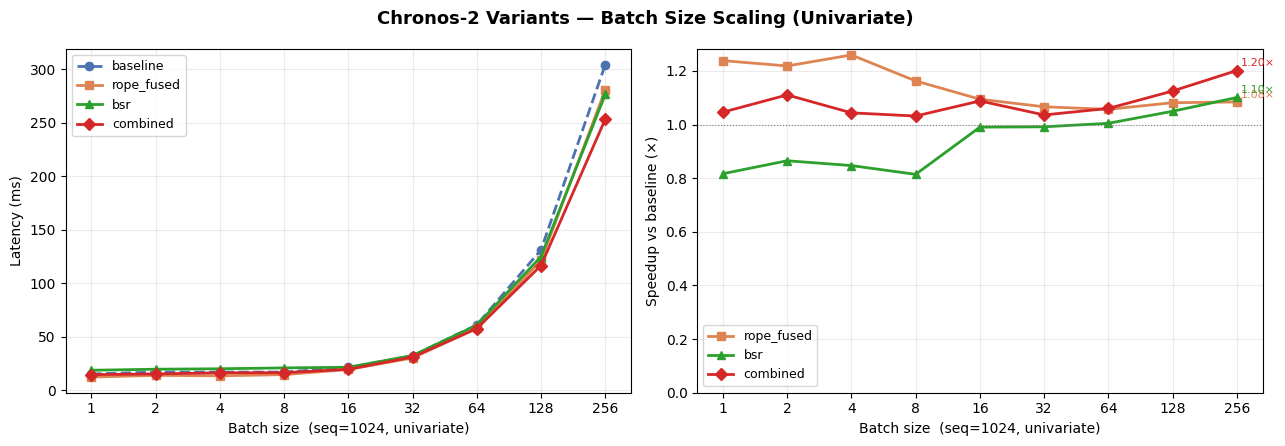

Saved → artifacts/combined_benchmark/scaling_batch_univariate.png


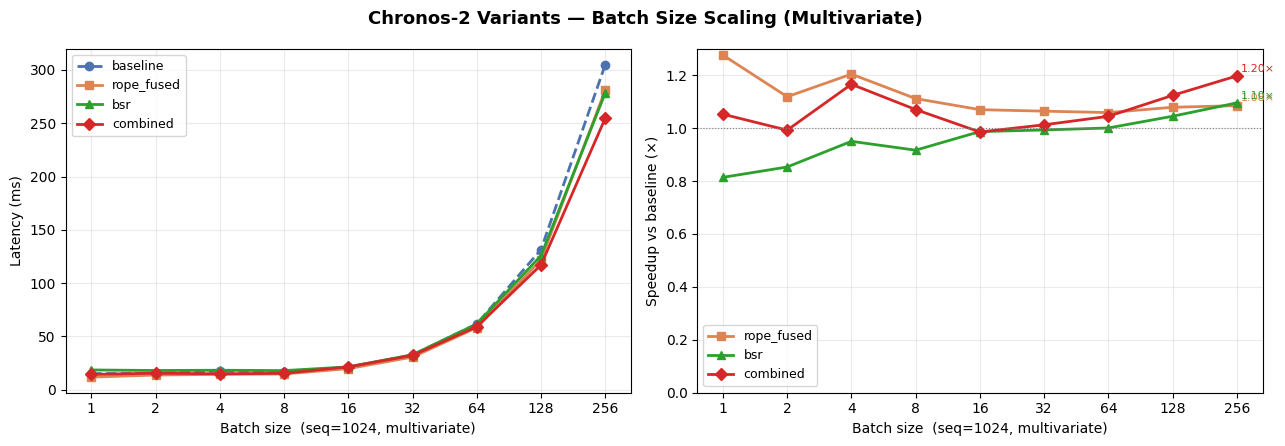

Saved → artifacts/combined_benchmark/scaling_batch_multivariate.png


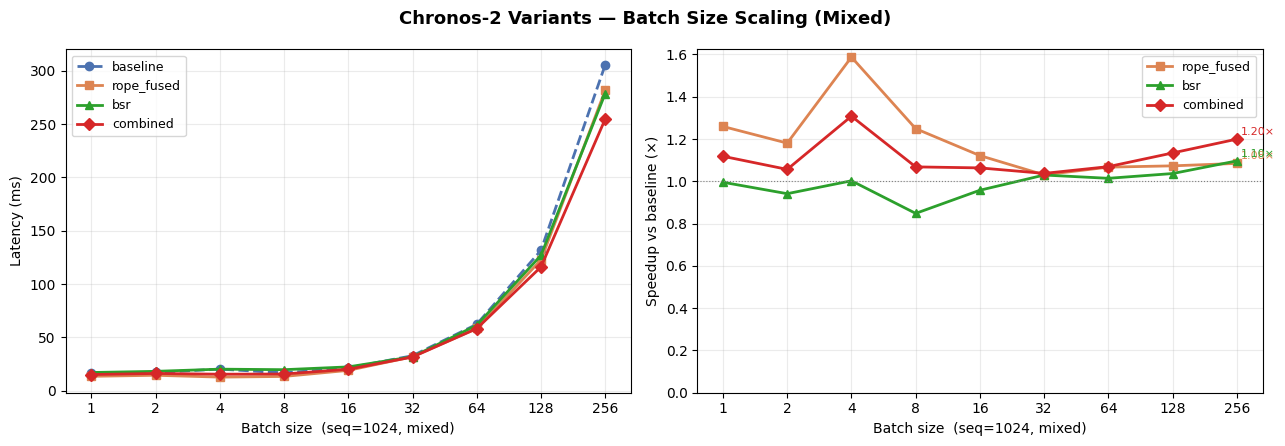

Saved → artifacts/combined_benchmark/scaling_batch_mixed.png


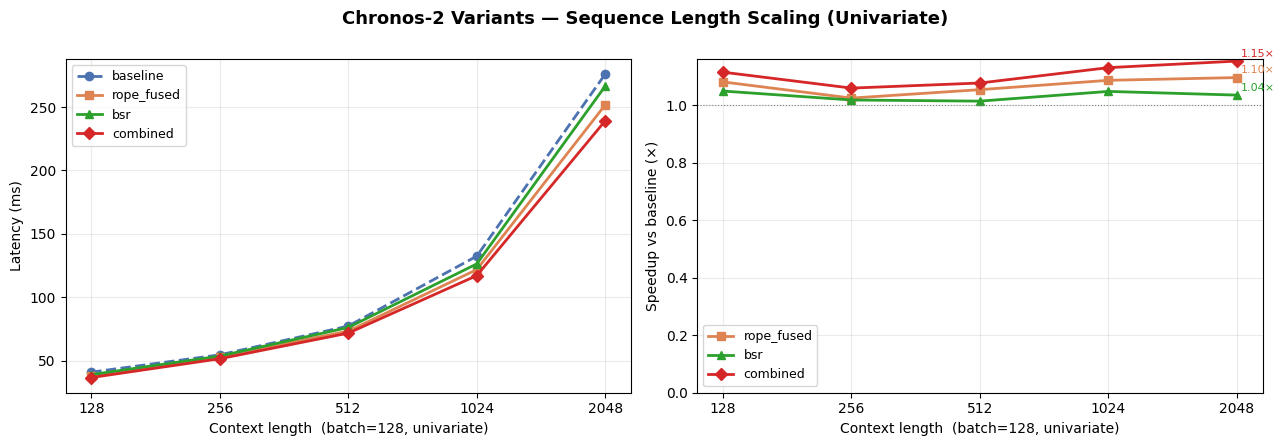

Saved → artifacts/combined_benchmark/scaling_seq_univariate.png


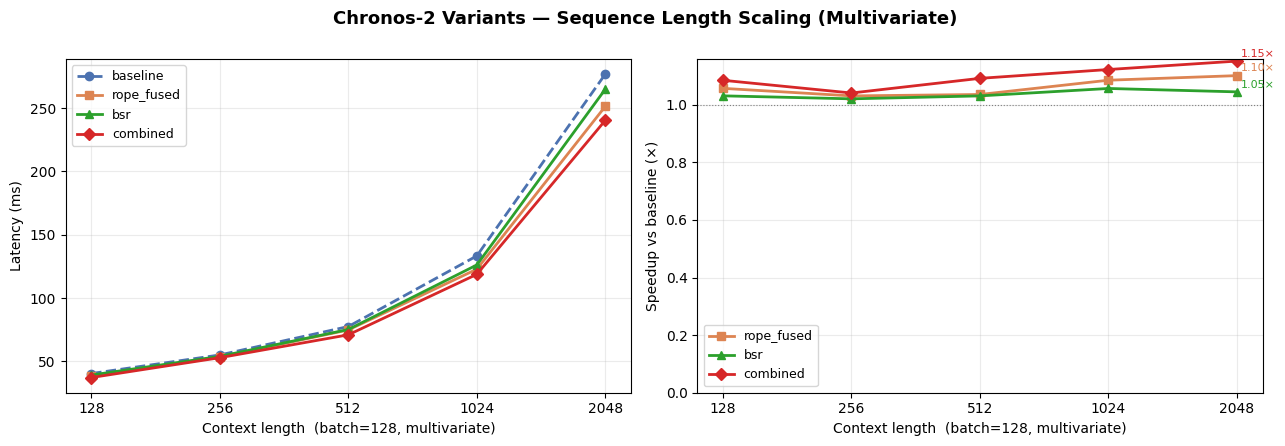

Saved → artifacts/combined_benchmark/scaling_seq_multivariate.png


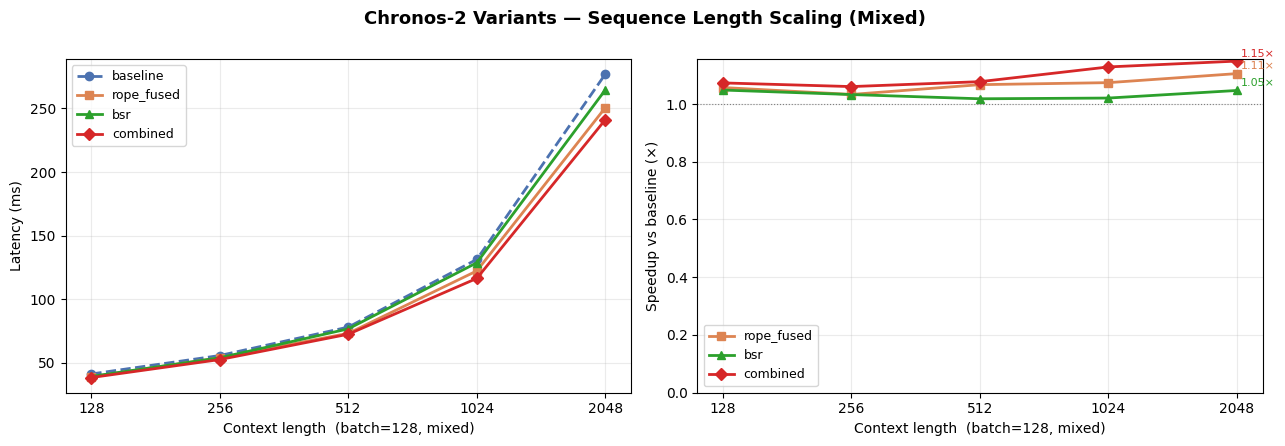

Saved → artifacts/combined_benchmark/scaling_seq_mixed.png


In [8]:
def _plot_sweep(x_vals, results_dict, x_label, title, save_path,
                speedup_ref='baseline', vline=None, vline_label=None):
    """Two-panel figure: (left) absolute latency, (right) speedup vs baseline."""
    fig, (ax_lat, ax_su) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    base_ms = np.array(results_dict[speedup_ref])

    for name in model_names:
        ms      = np.array(results_dict[name])
        speedup = base_ms / ms
        ls      = '--' if name == 'baseline' else '-'
        ax_lat.plot(x_vals, ms,      marker=MARKERS[name], ls=ls, color=COLORS[name], lw=2.0, label=name)
        if name != speedup_ref:
            ax_su.plot(x_vals, speedup, marker=MARKERS[name], ls='-', color=COLORS[name], lw=2.0, label=name)
            ax_su.annotate(f'{speedup[-1]:.2f}×',
                           xy=(x_vals[-1], speedup[-1]),
                           xytext=(3, 3), textcoords='offset points',
                           fontsize=8, color=COLORS[name])

    ax_su.axhline(1.0, color='grey', lw=0.8, ls=':')
    if vline is not None:
        for ax in (ax_lat, ax_su):
            ax.axvline(vline, color='#d62728', lw=1.5, ls=':', label=vline_label or str(vline))

    for ax, ylabel in ((ax_lat, 'Latency (ms)'), (ax_su, 'Speedup vs baseline (×)')):
        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_xscale('log', base=2)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())
        ax.set_xticks(x_vals)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=9)

    ax_su.set_ylim(bottom=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


# Batch sweep — all variate modes
for mode in VARIATE_MODES:
    _plot_sweep(
        BATCH_SIZES, batch_results[mode],
        x_label=f'Batch size  (seq={SWEEP_SEQ}, {mode})',
        title=f'Chronos-2 Variants — Batch Size Scaling ({mode.capitalize()})',
        save_path=OUTPUT_DIR / f'scaling_batch_{mode}.png',
    )

# Sequence length sweep — all variate modes
for mode in VARIATE_MODES:
    _plot_sweep(
        SEQ_LENS, seq_results[mode],
        x_label=f'Context length  (batch={FIXED_BATCH}, {mode})',
        title=f'Chronos-2 Variants — Sequence Length Scaling ({mode.capitalize()})',
        save_path=OUTPUT_DIR / f'scaling_seq_{mode}.png',
    )


## 9. GPU Memory Analysis

Measures **peak transient** allocated bytes above the static model weight baseline during a single forward pass.

Two sweeps:
- **Seq-length sweep** at fixed batch = 4
- **Batch-size sweep** at fixed seq = 1024

In [9]:
SEQ_LENS_MEM    = [128, 256, 512, 1024, 2048]
FIXED_BATCH_MEM = 4

mem_seq = {mode: {name: [] for name in model_names} for mode in VARIATE_MODES}

for mode in VARIATE_MODES:
    if mode == 'univariate':
        _gids_mem = torch.arange(FIXED_BATCH_MEM, dtype=torch.long, device=DEVICE)
    elif mode == 'multivariate':
        _gids_mem = torch.zeros(FIXED_BATCH_MEM, dtype=torch.long, device=DEVICE)
    else:  # mixed
        half = FIXED_BATCH_MEM // 2
        _gids_mem = torch.cat([
            torch.zeros(half, dtype=torch.long),
            torch.ones(FIXED_BATCH_MEM - half, dtype=torch.long),
        ]).to(DEVICE)

    print(f'\nPeak transient memory — seq sweep  (batch={FIXED_BATCH_MEM}, {mode})')
    print(f"{'SeqLen':>7}  " + "  ".join(f"{n:>14}" for n in model_names))
    print('-' * 72)

    for seq in SEQ_LENS_MEM:
        ctx = torch.randn(FIXED_BATCH_MEM, seq, device=DEVICE)
        row = [f'{seq:>7}']
        for name, m in MODELS.items():
            gids_cap = _gids_mem
            def _fwd(m=m, ctx=ctx, gids=gids_cap): m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)
            mem = measure_peak_memory(_fwd)['transient']
            mem_seq[mode][name].append(mem)
            row.append(f'{fmt_mb(mem):>14}')
        print('  '.join(row))



Peak transient memory — seq sweep  (batch=4, univariate)
 SeqLen        baseline      rope_fused             bsr        combined
------------------------------------------------------------------------
    128          4.2 MB          2.8 MB          7.9 MB          7.9 MB
    256          6.2 MB          4.4 MB         11.9 MB         11.9 MB
    512          7.7 MB          5.2 MB         14.9 MB         14.9 MB
   1024         12.6 MB          8.6 MB         24.7 MB         24.7 MB
   2048         24.1 MB         15.6 MB         47.2 MB         47.2 MB

Peak transient memory — seq sweep  (batch=4, multivariate)
 SeqLen        baseline      rope_fused             bsr        combined
------------------------------------------------------------------------
    128          4.2 MB          2.8 MB          7.9 MB          7.9 MB
    256          6.2 MB          4.4 MB         11.9 MB         11.9 MB
    512          7.7 MB          5.2 MB         14.9 MB         14.9 MB
   1024         

In [1]:
BATCH_SIZES_MEM = [8, 16, 32, 64, 128, 256, 512]
FIXED_SEQ_MEM   = 1024

mem_batch = {mode: {name: [] for name in model_names} for mode in VARIATE_MODES}

for mode in VARIATE_MODES:
    print(f'\nPeak transient memory — batch sweep  (seq={FIXED_SEQ_MEM}, {mode})')
    print(f"{'Batch':>6}  " + "  ".join(f"{n:>14}" for n in model_names))
    print('-' * 72)

    for bs in BATCH_SIZES_MEM:
        ctx = torch.randn(bs, FIXED_SEQ_MEM, device=DEVICE)
        if mode == 'univariate':
            gids = torch.arange(bs, dtype=torch.long, device=DEVICE)
        elif mode == 'multivariate':
            gids = torch.zeros(bs, dtype=torch.long, device=DEVICE)
        else:  # mixed
            half = max(1, bs // 2)
            gids = torch.cat([
                torch.zeros(half, dtype=torch.long),
                torch.ones(bs - half, dtype=torch.long),
            ]).to(DEVICE)

        row = [f'{bs:>6}']
        for name, m in MODELS.items():
            gids_cap = gids
            def _fwd(m=m, ctx=ctx, gids=gids_cap): m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)
            mem = measure_peak_memory(_fwd)['transient']
            mem_batch[mode][name].append(mem)
            row.append(f'{fmt_mb(mem):>14}')
        print('  '.join(row))
        torch.cuda.empty_cache() if torch.cuda.is_available() else None


NameError: name 'VARIATE_MODES' is not defined

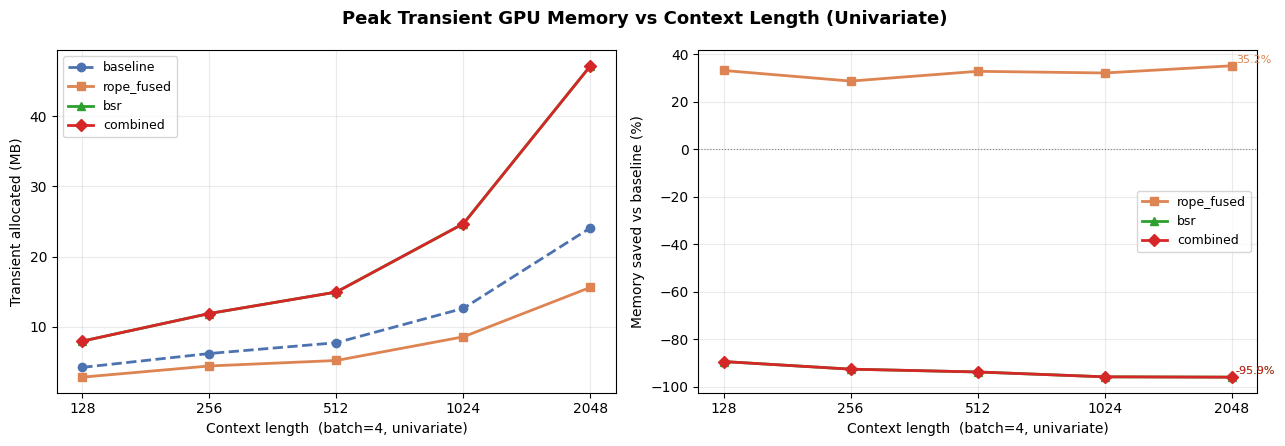

Saved → artifacts/combined_benchmark/memory_seq_univariate.png


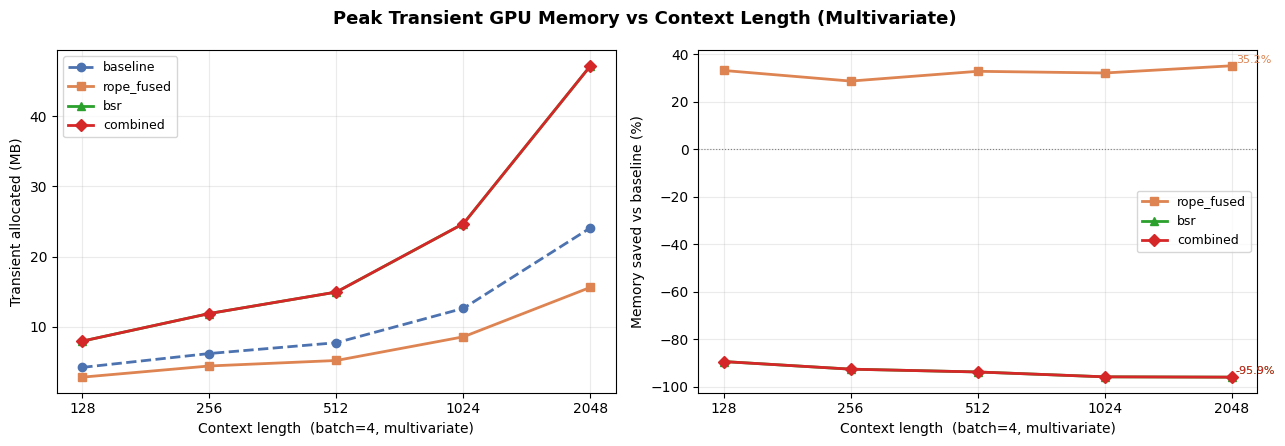

Saved → artifacts/combined_benchmark/memory_seq_multivariate.png


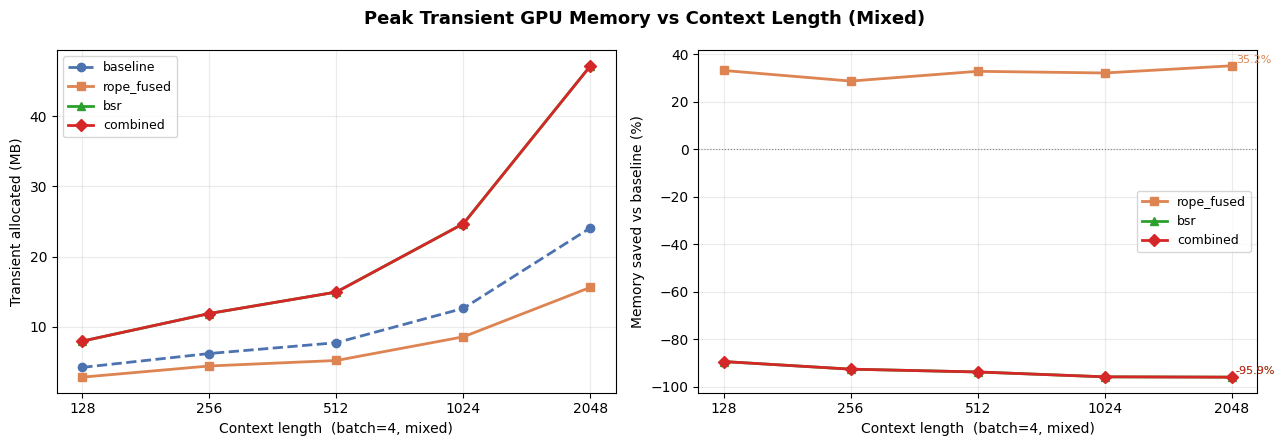

Saved → artifacts/combined_benchmark/memory_seq_mixed.png


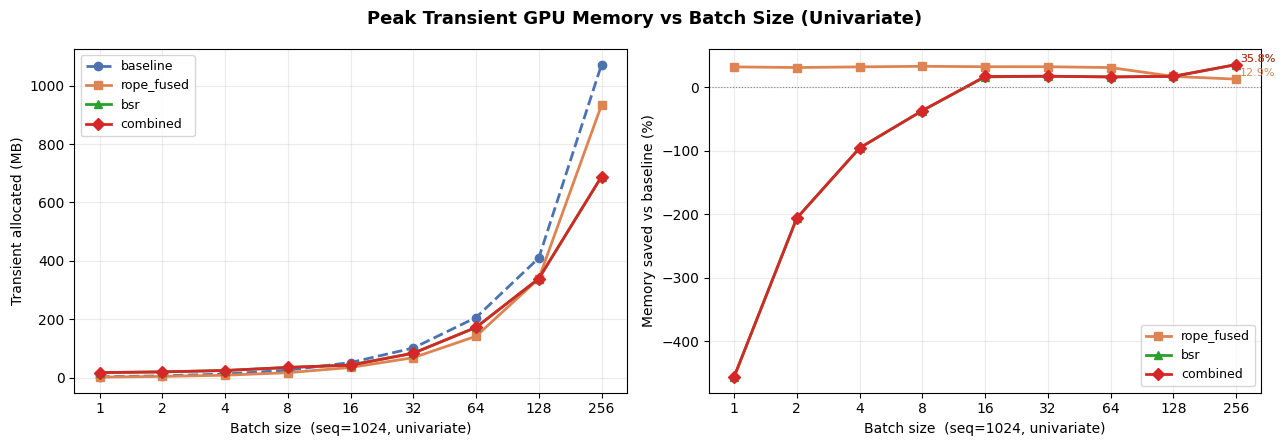

Saved → artifacts/combined_benchmark/memory_batch_univariate.png


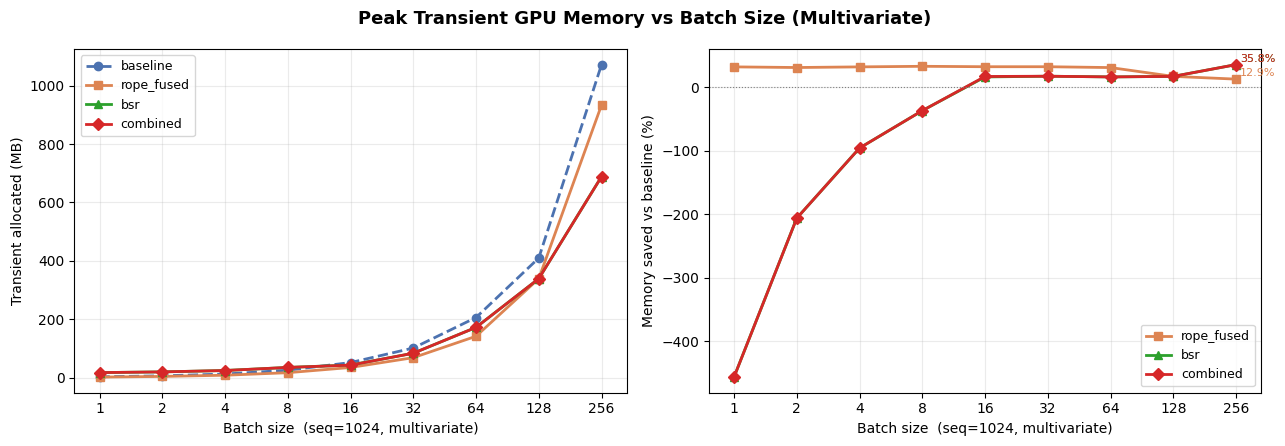

Saved → artifacts/combined_benchmark/memory_batch_multivariate.png


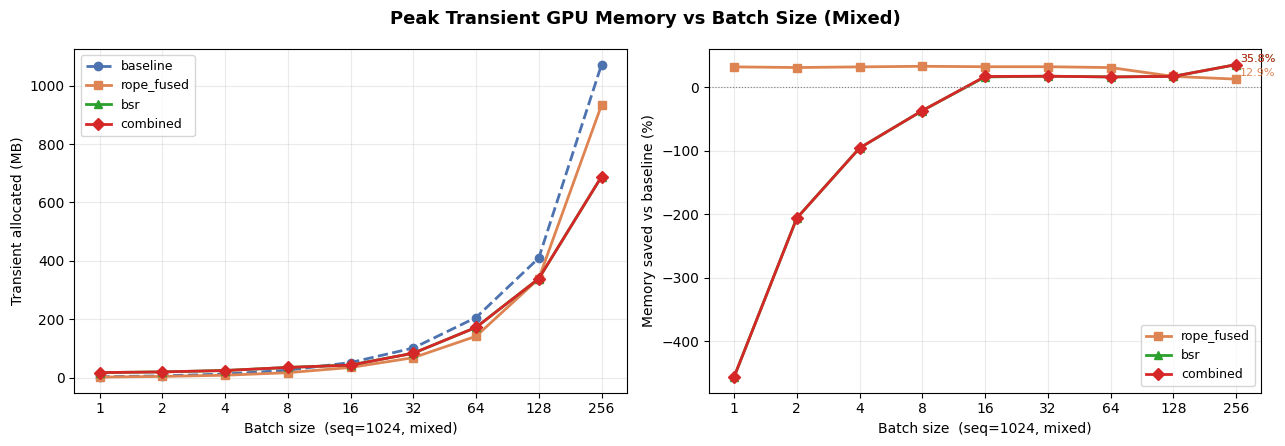

Saved → artifacts/combined_benchmark/memory_batch_mixed.png


In [12]:
def _plot_memory(x_vals, mem_dict, x_label, title, save_path):
    fig, (ax_abs, ax_save) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    base_mb = np.array(mem_dict['baseline']) / 1024**2

    for name in model_names:
        mb = np.array(mem_dict[name]) / 1024**2
        ls = '--' if name == 'baseline' else '-'
        ax_abs.plot(x_vals, mb, marker=MARKERS[name], ls=ls, color=COLORS[name], lw=2.0, label=name)

    ax_abs.set_xlabel(x_label, fontsize=10)
    ax_abs.set_ylabel('Transient allocated (MB)', fontsize=10)
    ax_abs.set_xscale('log', base=2)
    ax_abs.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax_abs.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax_abs.set_xticks(x_vals)
    ax_abs.legend(fontsize=9)
    ax_abs.grid(True, alpha=0.25)

    # Savings relative to baseline
    for name in model_names:
        if name == 'baseline':
            continue
        mb    = np.array(mem_dict[name]) / 1024**2
        saved = np.where(base_mb > 0, 100.0 * (base_mb - mb) / base_mb, 0.0)
        ax_save.plot(x_vals, saved, marker=MARKERS[name], ls='-', color=COLORS[name], lw=2.0, label=name)
        ax_save.annotate(f'{saved[-1]:.1f}%',
                         xy=(x_vals[-1], saved[-1]),
                         xytext=(3, 2), textcoords='offset points',
                         fontsize=8, color=COLORS[name])

    ax_save.axhline(0, color='grey', lw=0.8, ls=':')
    ax_save.set_xlabel(x_label, fontsize=10)
    ax_save.set_ylabel('Memory saved vs baseline (%)', fontsize=10)
    ax_save.set_xscale('log', base=2)
    ax_save.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax_save.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax_save.set_xticks(x_vals)
    ax_save.legend(fontsize=9)
    ax_save.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


# Memory — seq sweep — all variate modes
for mode in VARIATE_MODES:
    _plot_memory(
        SEQ_LENS_MEM, mem_seq[mode],
        x_label=f'Context length  (batch={FIXED_BATCH_MEM}, {mode})',
        title=f'Peak Transient GPU Memory vs Context Length ({mode.capitalize()})',
        save_path=OUTPUT_DIR / f'memory_seq_{mode}.png',
    )

# Memory — batch sweep — all variate modes
for mode in VARIATE_MODES:
    _plot_memory(
        BATCH_SIZES_MEM, mem_batch[mode],
        x_label=f'Batch size  (seq={FIXED_SEQ_MEM}, {mode})',
        title=f'Peak Transient GPU Memory vs Batch Size ({mode.capitalize()})',
        save_path=OUTPUT_DIR / f'memory_batch_{mode}.png',
    )


## 10. Summary

In [13]:
import pandas as pd

# ── Latency speedup table for each variate mode — batch sweep ───────────────
for mode in VARIATE_MODES:
    print(f'\nSpeedup vs baseline — batch sweep, {mode}, seq={SWEEP_SEQ}')
    rows = []
    for i, bs in enumerate(BATCH_SIZES):
        base_t = batch_results[mode]['baseline'][i]
        row = {'batch': bs}
        for name in model_names:
            if name != 'baseline':
                row[f'{name}_speedup'] = round(base_t / batch_results[mode][name][i], 3)
        rows.append(row)
    df = pd.DataFrame(rows).set_index('batch')
    print(df.to_string())

# ── Latency speedup table for each variate mode — seq sweep ─────────────────
for mode in VARIATE_MODES:
    print(f'\nSpeedup vs baseline — seq sweep, {mode}, batch={FIXED_BATCH}')
    rows = []
    for i, seq in enumerate(SEQ_LENS):
        base_t = seq_results[mode]['baseline'][i]
        row = {'seq': seq}
        for name in model_names:
            if name != 'baseline':
                row[f'{name}_speedup'] = round(base_t / seq_results[mode][name][i], 3)
        rows.append(row)
    df = pd.DataFrame(rows).set_index('seq')
    print(df.to_string())

# ── Memory savings at largest seq ────────────────────────────────────────────
print(f'\nPeak transient memory @ seq={SEQ_LENS_MEM[-1]}, batch={FIXED_BATCH_MEM}')
for mode in VARIATE_MODES:
    base_mem = mem_seq[mode]['baseline'][-1]
    print(f'\n  {mode}:')
    print(f"    baseline   : {fmt_mb(base_mem)}")
    for name in model_names:
        if name == 'baseline':
            continue
        m   = mem_seq[mode][name][-1]
        pct = 100 * (base_mem - m) / base_mem if base_mem > 0 else float('nan')
        print(f'    {name:<12}: {fmt_mb(m)}   ({pct:+.1f}% vs baseline)')

# ── Save plots list ──────────────────────────────────────────────────────────
print(f'\nPlots saved to {OUTPUT_DIR}/')
for p in sorted(OUTPUT_DIR.glob('*.png')):
    print(f'  {p.name}')



Speedup vs baseline — batch sweep, univariate, seq=1024
       rope_fused_speedup  bsr_speedup  combined_speedup
batch                                                   
1                   1.238        0.817             1.046
2                   1.218        0.865             1.111
4                   1.259        0.847             1.044
8                   1.163        0.814             1.032
16                  1.094        0.990             1.088
32                  1.066        0.992             1.036
64                  1.057        1.005             1.060
128                 1.081        1.049             1.125
256                 1.084        1.101             1.201

Speedup vs baseline — batch sweep, multivariate, seq=1024
       rope_fused_speedup  bsr_speedup  combined_speedup
batch                                                   
1                   1.276        0.814             1.052
2                   1.119        0.853             0.992
4                   1.204    